# Experiment: LDA Solvers in Batch vs Streaming Mode (OpenML MNIST)

Objective:
- Compare `LinearDiscriminantAnalysis` solvers (`svd`, `lsqr`, `eigen`) in full-batch (`fit`) and streaming (`partial_fit`) training.
- Measure holdout accuracy, uninstrumented training time, and memory profile over 5-fold stratified cross-validation.
- Use a much larger real dataset from OpenML: `mnist_784` (70,000 samples, 784 features, 10 classes).


In [1]:
from __future__ import annotations

import tracemalloc
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import fetch_openml
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, StratifiedShuffleSplit


## Dataset and benchmark configuration

This setup keeps the training protocol fixed while changing only the LDA solver and training mode.


In [2]:
SEED = 42
N_SPLITS = 5
STREAM_BATCH_SIZES = (512, 2048, 8192)
BATCH_FIT_LABEL = 'full-fit'
MEASURE_MEMORY = True

OPENML_DATASET = 'mnist_784'
OPENML_VERSION = 1
# Set to None to run all 70,000 samples.
MAX_SAMPLES = 40_000

SOLVERS = ('svd', 'lsqr', 'eigen')
MODES = ('batch', 'streaming')
# Mild shrinkage improves numerical stability for covariance-based solvers.
SOLVER_PARAMS = {
    'svd': {},
    'lsqr': {'shrinkage': 1e-3},
    'eigen': {'shrinkage': 1e-3},
}


def load_openml_dataset(name: str, version: int):
    # `parser` is available in newer sklearn; fallback keeps compatibility.
    try:
        return fetch_openml(name=name, version=version, as_frame=False, parser="auto")
    except TypeError:
        return fetch_openml(name=name, version=version, as_frame=False)


mnist = load_openml_dataset(OPENML_DATASET, OPENML_VERSION)
X = np.asarray(mnist.data, dtype=np.float32)
y = np.asarray(mnist.target).astype(np.int64, copy=False)
source_samples = X.shape[0]

if MAX_SAMPLES is not None and MAX_SAMPLES < source_samples:
    splitter = StratifiedShuffleSplit(n_splits=1, train_size=MAX_SAMPLES, random_state=SEED)
    subset_idx, _ = next(splitter.split(X, y))
    X = X[subset_idx]
    y = y[subset_idx]

CLASSES = np.unique(y)

print(f"Dataset: OpenML/{OPENML_DATASET} (v{OPENML_VERSION})")
print(f"Samples={X.shape[0]} (from {source_samples}), Features={X.shape[1]}, Classes={len(CLASSES)}")
print(f"Solvers={SOLVERS}, Modes={MODES}, Folds={N_SPLITS}")
print(f"Streaming batch-size sweep={STREAM_BATCH_SIZES}")
print(f"Memory profiling enabled={MEASURE_MEMORY}")


Dataset: OpenML/mnist_784 (v1)
Samples=40000 (from 70000), Features=784, Classes=10
Solvers=('svd', 'lsqr', 'eigen'), Modes=('batch', 'streaming'), Folds=5
Streaming batch-size sweep=(512, 2048, 8192)
Memory profiling enabled=True


## Helpers

- `fit` mode trains once on the whole training fold.
- `partial_fit` mode streams mini-batches through the same fold (first chunk passes `classes`, subsequent chunks omit it).
- Streaming is evaluated across a sweep of `STREAM_BATCH_SIZES`.
- `train_time_s` is measured without `tracemalloc`; `train_time_mem_s` and `peak_mem_mb` are measured in a separate profiled run.


In [3]:
def build_estimator(solver: str) -> LinearDiscriminantAnalysis:
    return LinearDiscriminantAnalysis(solver=solver, **SOLVER_PARAMS[solver])


def fit_streaming(
    estimator: LinearDiscriminantAnalysis,
    X_train: np.ndarray,
    y_train: np.ndarray,
    classes: np.ndarray,
    batch_size: int,
) -> LinearDiscriminantAnalysis:
    n_samples = X_train.shape[0]
    for start in range(0, n_samples, batch_size):
        stop = min(start + batch_size, n_samples)
        X_chunk = X_train[start:stop]
        y_chunk = y_train[start:stop]
        if start == 0:
            estimator.partial_fit(
                X_chunk,
                y_chunk,
                classes=classes,
            )
        else:
            estimator.partial_fit(
                X_chunk,
                y_chunk,
            )
    return estimator


def benchmark_training(train_builder, *, measure_memory: bool):
    t0 = perf_counter()
    model = train_builder()
    train_time_s = perf_counter() - t0

    train_time_mem_s = np.nan
    peak_mem_mb = np.nan
    if measure_memory:
        tracemalloc.start()
        t1 = perf_counter()
        _ = train_builder()
        train_time_mem_s = perf_counter() - t1
        _, peak_bytes = tracemalloc.get_traced_memory()
        tracemalloc.stop()
        peak_mem_mb = peak_bytes / (1024 ** 2)

    return model, train_time_s, train_time_mem_s, peak_mem_mb


## Run 5-fold holdout benchmark


In [4]:
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
records = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    rng = np.random.default_rng(SEED + fold_idx)
    order = rng.permutation(X_train.shape[0])
    X_train_stream = X_train[order]
    y_train_stream = y_train[order]

    for solver in SOLVERS:
        batch_builder = lambda solver=solver: build_estimator(solver).fit(X_train, y_train)
        batch_model, train_time_s, train_time_mem_s, peak_mem_mb = benchmark_training(
            batch_builder,
            measure_memory=MEASURE_MEMORY,
        )
        batch_acc = accuracy_score(y_test, batch_model.predict(X_test))
        records.append(
            {
                'fold': fold_idx,
                'solver': solver,
                'mode': 'batch',
                'batch_size': BATCH_FIT_LABEL,
                'accuracy': batch_acc,
                'train_time_s': train_time_s,
                'train_time_mem_s': train_time_mem_s,
                'peak_mem_mb': peak_mem_mb,
            }
        )

        for batch_size in STREAM_BATCH_SIZES:
            streaming_builder = lambda solver=solver, batch_size=batch_size: fit_streaming(
                build_estimator(solver),
                X_train_stream,
                y_train_stream,
                classes=CLASSES,
                batch_size=batch_size,
            )
            stream_model, train_time_s, train_time_mem_s, peak_mem_mb = benchmark_training(
                streaming_builder,
                measure_memory=MEASURE_MEMORY,
            )
            stream_acc = accuracy_score(y_test, stream_model.predict(X_test))
            records.append(
                {
                    'fold': fold_idx,
                    'solver': solver,
                    'mode': 'streaming',
                    'batch_size': int(batch_size),
                    'accuracy': stream_acc,
                    'train_time_s': train_time_s,
                    'train_time_mem_s': train_time_mem_s,
                    'peak_mem_mb': peak_mem_mb,
                }
            )

expected_rows = N_SPLITS * len(SOLVERS) * (1 + len(STREAM_BATCH_SIZES))
print(f'Collected {len(records)} rows (expected {expected_rows}).')
records[:6]


Collected 60 rows (expected 60).


[{'fold': 1,
  'solver': 'svd',
  'mode': 'batch',
  'batch_size': 'full-fit',
  'accuracy': 0.870125,
  'train_time_s': 0.7384855409618467,
  'train_time_mem_s': 0.7403444169904105,
  'peak_mem_mb': 404.1385259628296},
 {'fold': 1,
  'solver': 'svd',
  'mode': 'streaming',
  'batch_size': 512,
  'accuracy': 0.86975,
  'train_time_s': 3.6816605830099434,
  'train_time_mem_s': 3.6209119590348564,
  'peak_mem_mb': 52.47802448272705},
 {'fold': 1,
  'solver': 'svd',
  'mode': 'streaming',
  'batch_size': 2048,
  'accuracy': 0.870125,
  'train_time_s': 1.7846742499968968,
  'train_time_mem_s': 1.6922303339815699,
  'peak_mem_mb': 90.28202152252197},
 {'fold': 1,
  'solver': 'svd',
  'mode': 'streaming',
  'batch_size': 8192,
  'accuracy': 0.871875,
  'train_time_s': 1.2102686669677496,
  'train_time_mem_s': 1.0639844160177745,
  'peak_mem_mb': 218.91283702850342},
 {'fold': 1,
  'solver': 'lsqr',
  'mode': 'batch',
  'batch_size': 'full-fit',
  'accuracy': 0.871375,
  'train_time_s': 0.515

## Aggregate metrics (mean +/- std across folds, by solver/mode/batch size)


In [5]:
METRICS = ('accuracy', 'train_time_s', 'train_time_mem_s', 'peak_mem_mb')


def summarize_records(records):
    summary = []
    for solver in SOLVERS:
        for mode in MODES:
            batch_sizes = (BATCH_FIT_LABEL,) if mode == 'batch' else STREAM_BATCH_SIZES
            for batch_size in batch_sizes:
                subset = [
                    r for r in records
                    if r['solver'] == solver
                    and r['mode'] == mode
                    and r['batch_size'] == batch_size
                ]
                if not subset:
                    continue
                row = {'solver': solver, 'mode': mode, 'batch_size': batch_size, 'n': len(subset)}
                for metric in METRICS:
                    values = np.array([r[metric] for r in subset], dtype=float)
                    finite = values[np.isfinite(values)]
                    if finite.size == 0:
                        row[f'{metric}_mean'] = np.nan
                        row[f'{metric}_std'] = np.nan
                    elif finite.size == 1:
                        row[f'{metric}_mean'] = finite[0]
                        row[f'{metric}_std'] = 0.0
                    else:
                        row[f'{metric}_mean'] = finite.mean()
                        row[f'{metric}_std'] = finite.std(ddof=1)
                summary.append(row)
    return summary


summary_rows = summarize_records(records)
summary_rows


[{'solver': 'svd',
  'mode': 'batch',
  'batch_size': 'full-fit',
  'n': 5,
  'accuracy_mean': 0.86445,
  'accuracy_std': 0.003263912529465225,
  'train_time_s_mean': 0.7416126245749183,
  'train_time_s_std': 0.01155447971389195,
  'train_time_mem_s_mean': 0.7312347001978197,
  'train_time_mem_s_std': 0.010912653393111819,
  'peak_mem_mb_mean': 404.1378046035767,
  'peak_mem_mb_std': 0.0013930204231295733},
 {'solver': 'svd',
  'mode': 'streaming',
  'batch_size': 512,
  'n': 5,
  'accuracy_mean': 0.864475,
  'accuracy_std': 0.003222722063721911,
  'train_time_s_mean': 3.6520448666182346,
  'train_time_s_std': 0.040591018749873885,
  'train_time_mem_s_mean': 3.6320366001920776,
  'train_time_mem_s_std': 0.035365930265677824,
  'peak_mem_mb_mean': 52.48964290618896,
  'peak_mem_mb_std': 0.03397097863180252},
 {'solver': 'svd',
  'mode': 'streaming',
  'batch_size': 2048,
  'n': 5,
  'accuracy_mean': 0.865375,
  'accuracy_std': 0.002734330356778432,
  'train_time_s_mean': 1.7879689667955

In [6]:
def fmt(mean, std, precision=4):
    if not np.isfinite(mean):
        return 'n/a'
    return f"{mean:.{precision}f} +/- {std:.{precision}f}"


def print_summary_table(summary_rows):
    header = (
        f"{'solver':<8} {'mode':<10} {'batch_size':<11} {'accuracy':>18} {'time_s':>18} {'time_mem_s':>18} {'peak_mem_mb':>18}"
    )
    print(header)
    print('-' * len(header))
    for row in summary_rows:
        acc = fmt(row['accuracy_mean'], row['accuracy_std'])
        t = fmt(row['train_time_s_mean'], row['train_time_s_std'])
        tm = fmt(row['train_time_mem_s_mean'], row['train_time_mem_s_std'])
        m = fmt(row['peak_mem_mb_mean'], row['peak_mem_mb_std'], precision=2)
        print(f"{row['solver']:<8} {row['mode']:<10} {str(row['batch_size']):<11} {acc:>18} {t:>18} {tm:>18} {m:>18}")


print_summary_table(summary_rows)


solver   mode       batch_size            accuracy             time_s         time_mem_s        peak_mem_mb
-----------------------------------------------------------------------------------------------------------
svd      batch      full-fit     0.8645 +/- 0.0033  0.7416 +/- 0.0116  0.7312 +/- 0.0109    404.14 +/- 0.00
svd      streaming  512          0.8645 +/- 0.0032  3.6520 +/- 0.0406  3.6320 +/- 0.0354     52.49 +/- 0.03
svd      streaming  2048         0.8654 +/- 0.0027  1.7880 +/- 0.0088  1.6760 +/- 0.0197     90.28 +/- 0.00
svd      streaming  8192         0.8661 +/- 0.0034  1.1964 +/- 0.0183  1.0625 +/- 0.0066    218.91 +/- 0.00
lsqr     batch      full-fit     0.8658 +/- 0.0031  0.4672 +/- 0.0603  0.4327 +/- 0.0354     41.73 +/- 0.00
lsqr     streaming  512          0.8658 +/- 0.0031  3.2612 +/- 0.0287  3.3218 +/- 0.0352     31.03 +/- 0.02
lsqr     streaming  2048         0.8658 +/- 0.0031  0.9232 +/- 0.0223  1.1621 +/- 0.5332     31.96 +/- 0.04
lsqr     streaming  8192    

## Visual comparison (streaming batch-size sweep per solver)


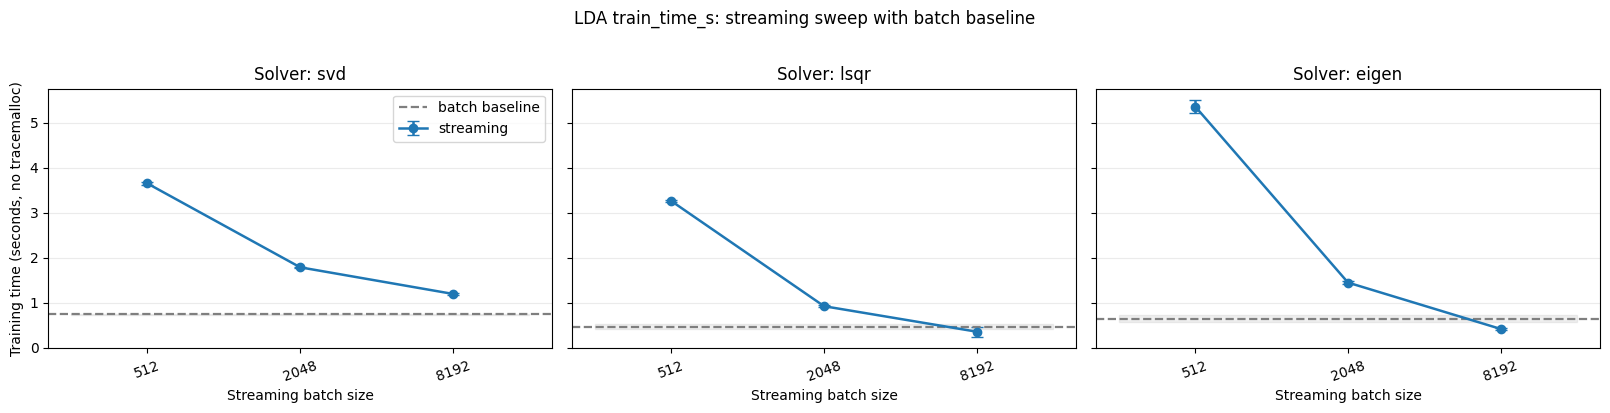

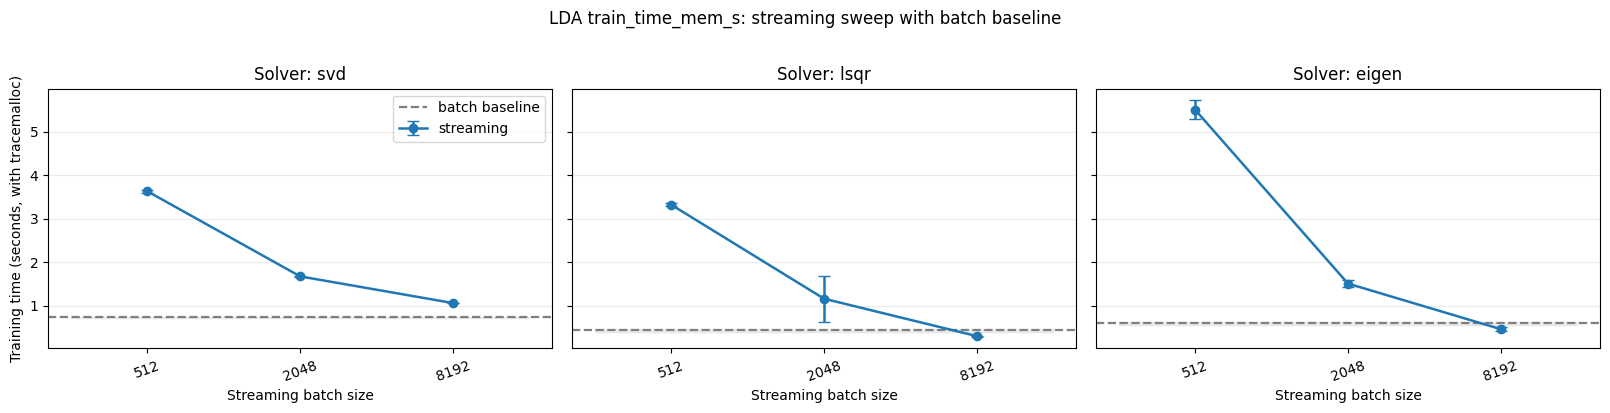

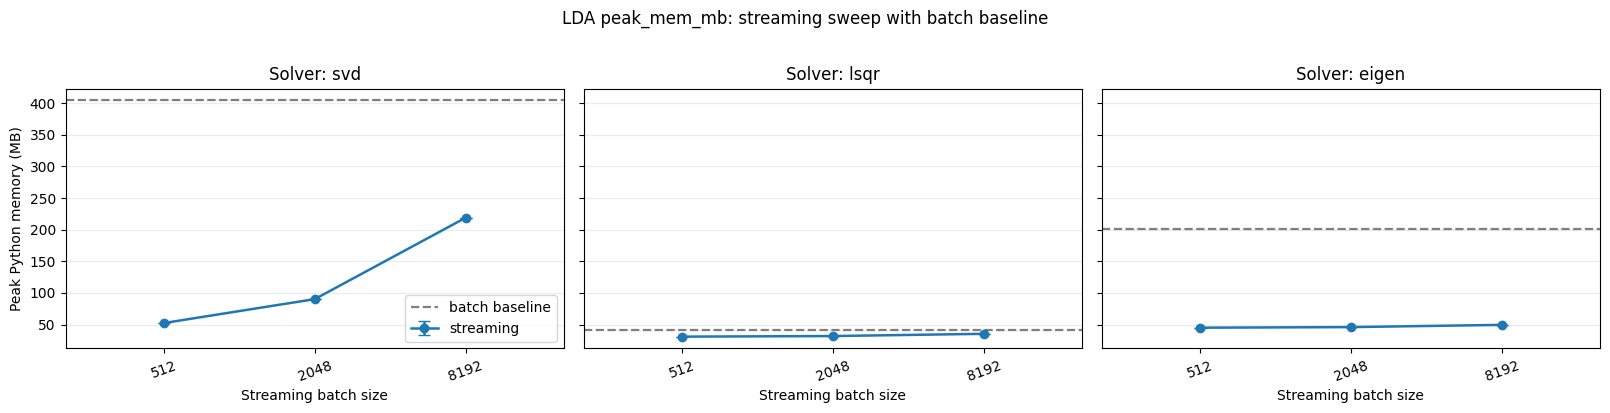

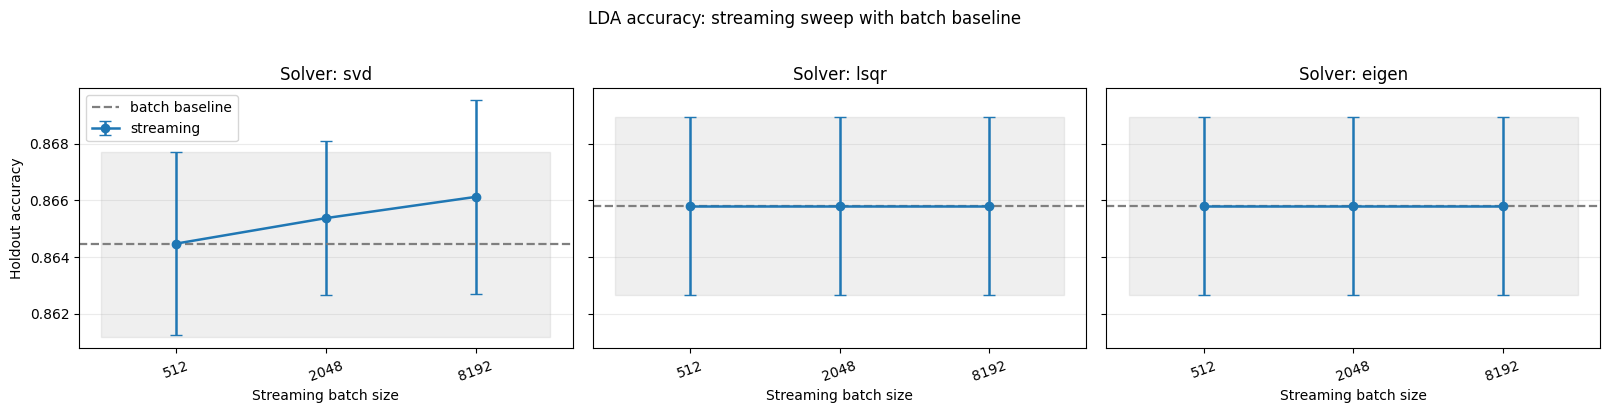

In [7]:
summary_lookup = {(r['solver'], r['mode'], r['batch_size']): r for r in summary_rows}
STREAM_BATCH_SIZES_SORTED = tuple(sorted(int(x) for x in STREAM_BATCH_SIZES))


def plot_streaming_sweep(metric: str, ylabel: str):
    fig, axes = plt.subplots(1, len(SOLVERS), figsize=(5.4 * len(SOLVERS), 4.0), sharey=True)
    if len(SOLVERS) == 1:
        axes = [axes]

    x = np.arange(len(STREAM_BATCH_SIZES_SORTED), dtype=float)
    x_labels = [str(bs) for bs in STREAM_BATCH_SIZES_SORTED]

    for ax, solver in zip(axes, SOLVERS):
        batch_row = summary_lookup[(solver, 'batch', BATCH_FIT_LABEL)]
        stream_rows = [summary_lookup[(solver, 'streaming', bs)] for bs in STREAM_BATCH_SIZES_SORTED]
        means = np.array([row[f'{metric}_mean'] for row in stream_rows], dtype=float)
        stds = np.array([row[f'{metric}_std'] for row in stream_rows], dtype=float)

        ax.errorbar(x, means, yerr=stds, marker='o', linewidth=1.8, capsize=4, label='streaming')

        baseline = batch_row[f'{metric}_mean']
        baseline_std = batch_row[f'{metric}_std']
        if np.isfinite(baseline):
            ax.axhline(baseline, color='tab:gray', linestyle='--', linewidth=1.6, label='batch baseline')
            if np.isfinite(baseline_std) and baseline_std > 0:
                ax.fill_between(
                    [-0.5, len(STREAM_BATCH_SIZES_SORTED) - 0.5],
                    baseline - baseline_std,
                    baseline + baseline_std,
                    color='tab:gray',
                    alpha=0.12,
                )

        ax.set_title(f"Solver: {solver}")
        ax.set_xlabel('Streaming batch size')
        ax.set_xticks(x)
        ax.set_xticklabels(x_labels, rotation=20)
        ax.grid(alpha=0.25, axis='y')

    axes[0].set_ylabel(ylabel)
    axes[0].legend(loc='best')
    fig.suptitle(f'LDA {metric}: streaming sweep with batch baseline', y=1.02)
    plt.tight_layout()
    plt.show()


plot_streaming_sweep('train_time_s', 'Training time (seconds, no tracemalloc)')
if MEASURE_MEMORY:
    plot_streaming_sweep('train_time_mem_s', 'Training time (seconds, with tracemalloc)')
    plot_streaming_sweep('peak_mem_mb', 'Peak Python memory (MB)')
plot_streaming_sweep('accuracy', 'Holdout accuracy')


## Quick takeaways from this run


In [8]:
def best(summary_rows, metric: str, higher_is_better: bool):
    key = f'{metric}_mean'
    valid = [row for row in summary_rows if np.isfinite(row[key])]
    if not valid:
        return None
    fn = max if higher_is_better else min
    return fn(valid, key=lambda row: row[key])


def describe_row(row):
    if row['mode'] == 'batch':
        return f"{row['solver']} batch ({row['batch_size']})"
    return f"{row['solver']} streaming (batch={row['batch_size']})"


best_acc = best(summary_rows, 'accuracy', higher_is_better=True)
fastest = best(summary_rows, 'train_time_s', higher_is_better=False)
lowest_mem = best(summary_rows, 'peak_mem_mb', higher_is_better=False)

if best_acc is not None:
    print('Best accuracy:', describe_row(best_acc), f"({best_acc['accuracy_mean']:.4f})")
if fastest is not None:
    print('Fastest training (no tracemalloc):', describe_row(fastest), f"({fastest['train_time_s_mean']:.4f} s)")
if lowest_mem is not None:
    print('Lowest peak memory:', describe_row(lowest_mem), f"({lowest_mem['peak_mem_mb_mean']:.2f} MB)")


Best accuracy: svd streaming (batch=8192) (0.8661)
Fastest training (no tracemalloc): lsqr streaming (batch=8192) (0.3559 s)
Lowest peak memory: lsqr streaming (batch=512) (31.03 MB)


# Next steps

- Set `MAX_SAMPLES = None` to run the full 70,000-sample benchmark once runtime is acceptable.
- Expand `STREAM_BATCH_SIZES` (or shift toward larger values) to further map throughput/memory regimes.
- Add another OpenML dataset (for example `Fashion-MNIST`) to test whether solver rankings are dataset-specific.

## Array API: NumPy vs PyTorch (SVD solver only)

The SVD path in both `fit` and `partial_fit` now supports the array API.
Below we compare training with NumPy arrays versus PyTorch CPU tensors,
verifying that predictions match and measuring any timing differences.

In [ ]:
import gc
import os
os.environ["SCIPY_ARRAY_API"] = "1"

import torch
from sklearn._config import config_context
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# Subsample BEFORE freeing the full dataset.
ARRAY_API_SAMPLES = 10_000
splitter = StratifiedShuffleSplit(
    n_splits=1, train_size=ARRAY_API_SAMPLES, random_state=SEED
)
api_idx, _ = next(splitter.split(X, y))
X_api = X[api_idx].copy()
y_api = y[api_idx].copy()

# Free the full dataset and all benchmark residuals to reclaim memory.
# The summary tables and plots are already rendered.
del X, y
for _name in list(globals()):
    if _name.startswith(("records", "summary", "batch_", "stream_",
                         "X_train", "X_test", "y_train", "y_test",
                         "mnist", "best_", "fastest", "lowest_")):
        try:
            del globals()[_name]
        except KeyError:
            pass
gc.collect()

train_idx, test_idx = next(
    StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED).split(
        X_api, y_api
    )
)
# Use float32 to keep memory low (torch SVD allocates aggressively).
X_train_np = X_api[train_idx].astype(np.float32)
y_train_np = y_api[train_idx]
X_test_np = X_api[test_idx].astype(np.float32)
y_test_np = y_api[test_idx]
del X_api, y_api

# Shuffled order for streaming
rng = np.random.default_rng(SEED + 1)
order = rng.permutation(X_train_np.shape[0])
X_train_stream_np = X_train_np[order]
y_train_stream_np = y_train_np[order]

# PyTorch tensors (CPU) — from_numpy shares underlying memory
X_train_pt = torch.from_numpy(X_train_np)
y_train_pt = torch.from_numpy(y_train_np)
X_test_pt = torch.from_numpy(X_test_np)
X_train_stream_pt = torch.from_numpy(X_train_stream_np)
y_train_stream_pt = torch.from_numpy(y_train_stream_np)

CLASSES_NP = np.unique(y_train_np)
CLASSES_PT = torch.from_numpy(CLASSES_NP)
ARRAY_API_BATCH_SIZE = 2048

print(f"Array API subset: {ARRAY_API_SAMPLES} samples from full dataset")
print(f"Train: {X_train_np.shape}, Test: {X_test_np.shape}")
print(f"NumPy dtype: {X_train_np.dtype}, Torch dtype: {X_train_pt.dtype}")
print(f"Streaming batch size: {ARRAY_API_BATCH_SIZE}")

In [ ]:
def run_fit(X_train, y_train, X_test, use_array_api=False):
    """Batch fit and predict, returning (model, predictions, elapsed)."""
    ctx = config_context(array_api_dispatch=True) if use_array_api else config_context()
    with ctx:
        clf = LinearDiscriminantAnalysis(solver="svd")
        t0 = perf_counter()
        clf.fit(X_train, y_train)
        elapsed = perf_counter() - t0
        preds = clf.predict(X_test)
    return clf, preds, elapsed


def run_partial_fit(X_train, y_train, X_test, classes, batch_size, use_array_api=False):
    """Streaming partial_fit and predict, returning (model, predictions, elapsed)."""
    ctx = config_context(array_api_dispatch=True) if use_array_api else config_context()
    with ctx:
        clf = LinearDiscriminantAnalysis(solver="svd")
        n = X_train.shape[0]
        t0 = perf_counter()
        for start in range(0, n, batch_size):
            stop = min(start + batch_size, n)
            kw = {"classes": classes} if start == 0 else {}
            clf.partial_fit(X_train[start:stop], y_train[start:stop], **kw)
        elapsed = perf_counter() - t0
        preds = clf.predict(X_test)
    return clf, preds, elapsed


# --- NumPy baseline (no array API dispatch) ---
np_fit_model, np_fit_preds, np_fit_time = run_fit(
    X_train_np, y_train_np, X_test_np
)
np_pf_model, np_pf_preds, np_pf_time = run_partial_fit(
    X_train_stream_np, y_train_stream_np, X_test_np, CLASSES_NP, ARRAY_API_BATCH_SIZE
)

# --- NumPy with array API dispatch enabled ---
np_api_fit_model, np_api_fit_preds, np_api_fit_time = run_fit(
    X_train_np, y_train_np, X_test_np, use_array_api=True
)
np_api_pf_model, np_api_pf_preds, np_api_pf_time = run_partial_fit(
    X_train_stream_np, y_train_stream_np, X_test_np, CLASSES_NP, ARRAY_API_BATCH_SIZE,
    use_array_api=True,
)

# --- PyTorch with array API dispatch ---
pt_fit_model, pt_fit_preds, pt_fit_time = run_fit(
    X_train_pt, y_train_pt, X_test_pt, use_array_api=True
)
pt_pf_model, pt_pf_preds, pt_pf_time = run_partial_fit(
    X_train_stream_pt, y_train_stream_pt, X_test_pt, CLASSES_PT, ARRAY_API_BATCH_SIZE,
    use_array_api=True,
)

print("Training complete.")

In [ ]:
def to_numpy(arr):
    """Convert predictions to numpy for comparison."""
    if isinstance(arr, torch.Tensor):
        return arr.cpu().numpy()
    return np.asarray(arr)


# --- Accuracy comparison ---
results = {
    "NumPy fit":              (np_fit_time,      accuracy_score(y_test_np, to_numpy(np_fit_preds))),
    "NumPy partial_fit":      (np_pf_time,       accuracy_score(y_test_np, to_numpy(np_pf_preds))),
    "NumPy (API) fit":        (np_api_fit_time,   accuracy_score(y_test_np, to_numpy(np_api_fit_preds))),
    "NumPy (API) partial_fit":(np_api_pf_time,    accuracy_score(y_test_np, to_numpy(np_api_pf_preds))),
    "PyTorch fit":            (pt_fit_time,       accuracy_score(y_test_np, to_numpy(pt_fit_preds))),
    "PyTorch partial_fit":    (pt_pf_time,        accuracy_score(y_test_np, to_numpy(pt_pf_preds))),
}

print(f"{'Backend':<26} {'Time (s)':>10} {'Accuracy':>10}")
print("-" * 48)
for label, (elapsed, acc) in results.items():
    print(f"{label:<26} {elapsed:>10.4f} {acc:>10.4f}")

# --- Verify predictions match across backends ---
print()
np_fit_pred_np = to_numpy(np_fit_preds)
for label, preds in [
    ("NumPy partial_fit", np_pf_preds),
    ("NumPy (API) fit", np_api_fit_preds),
    ("NumPy (API) partial_fit", np_api_pf_preds),
    ("PyTorch fit", pt_fit_preds),
    ("PyTorch partial_fit", pt_pf_preds),
]:
    match = np.array_equal(np_fit_pred_np, to_numpy(preds))
    mismatches = np.sum(np_fit_pred_np != to_numpy(preds))
    status = "MATCH" if match else f"{mismatches} differ"
    print(f"NumPy fit vs {label:<26}: {status}")

In [ ]:
# --- Bar chart: timing comparison ---
labels = list(results.keys())
times = [results[l][0] for l in labels]
accs = [results[l][1] for l in labels]
colors = ["#1f77b4", "#1f77b4", "#2ca02c", "#2ca02c", "#ff7f0e", "#ff7f0e"]
hatches = ["", "//", "", "//", "", "//"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(range(len(labels)), times, color=colors)
for bar, h in zip(bars, hatches):
    bar.set_hatch(h)
ax1.set_xticks(range(len(labels)))
ax1.set_xticklabels(labels, rotation=35, ha="right")
ax1.set_ylabel("Training time (s)")
ax1.set_title("SVD Training Time: NumPy vs PyTorch (Array API)")
ax1.grid(alpha=0.25, axis="y")

bars2 = ax2.bar(range(len(labels)), accs, color=colors)
for bar, h in zip(bars2, hatches):
    bar.set_hatch(h)
ax2.set_xticks(range(len(labels)))
ax2.set_xticklabels(labels, rotation=35, ha="right")
ax2.set_ylabel("Holdout accuracy")
ax2.set_title("SVD Accuracy: NumPy vs PyTorch (Array API)")
ax2.set_ylim(min(accs) - 0.005, max(accs) + 0.005)
ax2.grid(alpha=0.25, axis="y")

plt.tight_layout()
plt.show()